In [1]:
import pandas as pd

train_test = pd.read_csv("train-test.csv")

print(train_test.shape)
train_test.head()

(48000, 14)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [2]:
# Check data types and missing values
train_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  str    
 1   pickup        48000 non-null  str    
 2   delivery      48000 non-null  str    
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  str    
 9   weight        47700 non-null  float64
 10  date          48000 non-null  str    
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), str(5)
memory usage: 5.1 MB


In [3]:
# Summary statistics for numeric columns - look for impossible values
train_test.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [4]:
# How many negative weights are there?
print("Negative weights:", (train_test['weight'] < 0).sum())

# How many missing values per column?
print("\nMissing values:")
print(train_test.isna().sum()[train_test.isna().sum() > 0])

# Look at the most extreme posted_rate rows
print("\nTop 5 highest posted_rate rows:")
print(train_test.nlargest(5, 'posted_rate')[['load_id', 'distance', 'equipment', 'weight', 'posted_rate']])

Negative weights: 292

Missing values:
weight          300
market_index    374
dtype: int64

Top 5 highest posted_rate rows:
         load_id  distance equipment   weight  posted_rate
12184  TR-012185    2829.8   Dry Van  33153.0     25533.00
37764  TR-037765    2810.9   Dry Van  33674.0     24294.98
1466   TR-001467    2786.0    Reefer  30322.0     24140.21
17371  TR-017372    2777.6    Reefer  33158.0     23662.71
26235  TR-026236    2552.5   Dry Van  25665.0     23580.42


In [5]:
# Look at negative weight rows - is the magnitude otherwise normal?
negative_weights = train_test[train_test['weight'] < 0]
print(negative_weights['weight'].describe())

count      292.000000
mean    -31724.195205
std       8262.536326
min     -47500.000000
25%     -37284.250000
50%     -31821.500000
75%     -25928.500000
max      -5000.000000
Name: weight, dtype: float64


In [6]:
# Make a copy so we always have the original raw data if we need to double check something later
clean = train_test.copy()

# Fix 1: sign-flip bug in weight - take absolute value
clean['weight'] = clean['weight'].abs()

# Fix 2: drop rows with missing weight or market_index (small % of data)
before = len(clean)
clean = clean.dropna(subset=['weight', 'market_index'])
after = len(clean)

print(f"Dropped {before - after} rows ({(before - after) / before * 100:.2f}%)")
print(f"Remaining rows: {after}")

# Sanity check - confirm no more negative weights or missing values
print("Negative weights remaining:", (clean['weight'] < 0).sum())
print("Missing values remaining:\n", clean.isna().sum().sum())

Dropped 673 rows (1.40%)
Remaining rows: 47327
Negative weights remaining: 0
Missing values remaining:
 0


In [7]:
# What are the unique values in equipment?
print("Equipment types:", clean['equipment'].unique())

# How many unique pickup/delivery cities are there?
print("Unique pickup cities:", clean['pickup'].nunique())
print("Unique delivery cities:", clean['delivery'].nunique())

# What date range do we have?
clean['date'] = pd.to_datetime(clean['date'])
print("Date range:", clean['date'].min(), "to", clean['date'].max())

Equipment types: <StringArray>
['Dry Van', 'Reefer', 'Flatbed']
Length: 3, dtype: str
Unique pickup cities: 64
Unique delivery cities: 64
Date range: 2025-01-01 00:00:00 to 2025-10-31 00:00:00


In [8]:
# One-hot encode equipment (3 types -> 3 binary columns)
clean = pd.get_dummies(clean, columns=['equipment'], prefix='equipment')

# Extract useful numeric pieces from date
clean['month'] = clean['date'].dt.month
clean['day_of_year'] = clean['date'].dt.dayofyear

# Drop columns we won't use as model inputs:
# - city names (we have lat/lon instead)
# - load_id (just an identifier, not a predictive feature)
# - raw date (we extracted what we need from it)
clean = clean.drop(columns=['pickup', 'delivery', 'load_id', 'date'])

print(clean.columns.tolist())
clean.head()

['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer', 'month', 'day_of_year']


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate,equipment_Dry Van,equipment_Flatbed,equipment_Reefer,month,day_of_year
0,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,0.95684,2.39595,645.41,True,False,False,1,1
1,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,0.97623,2.43355,679.97,False,False,True,1,1
2,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,1.00971,1.84491,1802.54,True,False,False,1,1
3,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,0.94518,1.87712,1827.28,True,False,False,1,1
4,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,0.98480,2.56300,1380.28,False,False,True,1,1


In [9]:
from sklearn.model_selection import train_test_split

# Separate features (X) from what we're predicting (y)
X = clean.drop(columns=['posted_rate'])
y = clean['posted_rate']

# Split: 80% to train the model, 20% to test how well it does on unseen data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 37861
Testing rows: 9466


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the held-out test set
y_pred = model.predict(X_test)

# Evaluate: how far off were we, on average?
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $139.24
RMSE: $614.55
R²:   0.8296


In [11]:
# Build a comparison table
results = X_test.copy()
results['actual'] = y_test
results['predicted'] = y_pred
results['error'] = results['predicted'] - results['actual']
results['abs_error'] = results['error'].abs()

# Show the 10 worst predictions
print(results.nlargest(10, 'abs_error')[['distance', 'weight', 'actual', 'predicted', 'error']])

       distance   weight    actual    predicted         error
12184    2829.8  33153.0  25533.00  5383.534597 -20149.465403
40171    2283.4  32447.0  20361.89  4452.550052 -15909.339948
20245    2153.5  31758.0  17772.53  4582.520056 -13190.009944
19516    2021.0  33799.0  16229.57  4192.555578 -12037.014422
46516    1684.3  31536.0  14784.38  3564.550784 -11219.829216
20882    1869.7  19389.0  14561.21  3720.409090 -10840.800910
36929    1894.0  21740.0  14362.88  3654.602507 -10708.277493
28699    2396.0  36757.0  15165.13  4677.527458 -10487.602542
2223     1344.4  24751.0  12100.18  2418.286865  -9681.893135
47536    2782.4  25730.0  15003.55  5402.524422  -9601.025578


In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest R²:", r2_score(y_test, rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

# Now the real test: take one real row, and see what each model predicts
# for month=10 (seen in training) vs month=12 (never seen - like December)
sample = X_test.iloc[[0]].copy()

sample_month10 = sample.copy()
sample_month10['month'] = 10

sample_month12 = sample.copy()
sample_month12['month'] = 12

print("\n--- Linear Regression ---")
print("Predicted rate at month=10:", model.predict(sample_month10)[0])
print("Predicted rate at month=12:", model.predict(sample_month12)[0])

print("\n--- Random Forest ---")
print("Predicted rate at month=10:", rf_model.predict(sample_month10)[0])
print("Predicted rate at month=12:", rf_model.predict(sample_month12)[0])

Random Forest R²: 0.8202837322689657
Random Forest MAE: 129.67951297274456

--- Linear Regression ---
Predicted rate at month=10: 4904.211380913306
Predicted rate at month=12: 4834.326798760563

--- Random Forest ---
Predicted rate at month=10: 5275.0443
Predicted rate at month=12: 5275.0443


Matplotlib is building the font cache; this may take a moment.


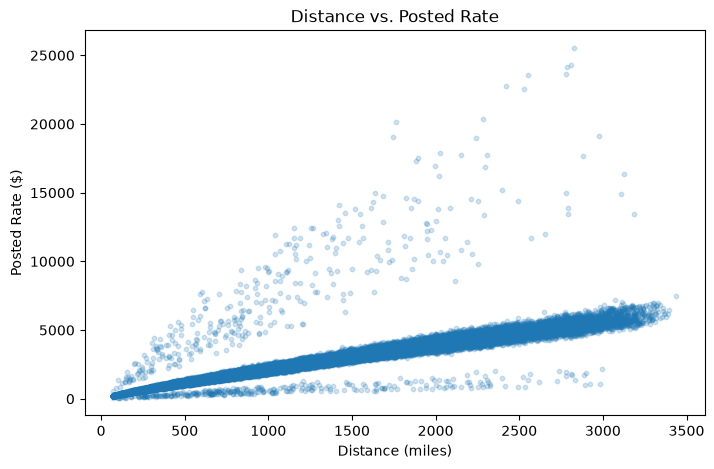

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(clean['distance'], clean['posted_rate'], alpha=0.2, s=10)
plt.xlabel('Distance (miles)')
plt.ylabel('Posted Rate ($)')
plt.title('Distance vs. Posted Rate')
plt.show()

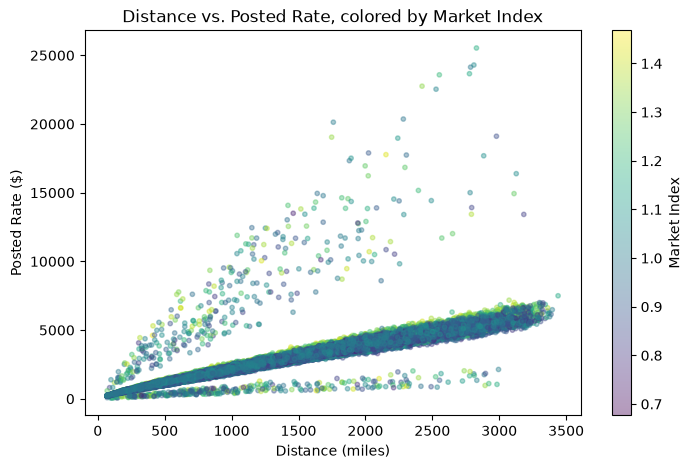

In [14]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(clean['distance'], clean['posted_rate'], 
                       c=clean['market_index'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Market Index')
plt.xlabel('Distance (miles)')
plt.ylabel('Posted Rate ($)')
plt.title('Distance vs. Posted Rate, colored by Market Index')
plt.show()

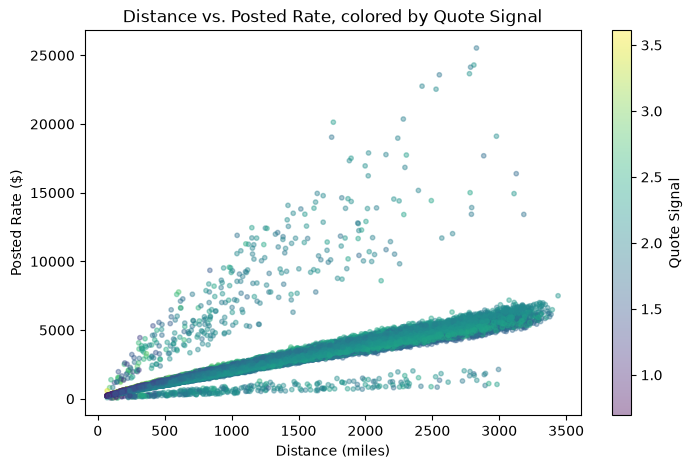

In [15]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(clean['distance'], clean['posted_rate'], 
                       c=clean['quote_signal'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Quote Signal')
plt.xlabel('Distance (miles)')
plt.ylabel('Posted Rate ($)')
plt.title('Distance vs. Posted Rate, colored by Quote Signal')
plt.show()

In [16]:
# Build interaction features: does distance's effect change based on market conditions?
X_train_v2 = X_train.copy()
X_test_v2 = X_test.copy()

X_train_v2['distance_x_market'] = X_train_v2['distance'] * X_train_v2['market_index']
X_train_v2['distance_x_quote'] = X_train_v2['distance'] * X_train_v2['quote_signal']

X_test_v2['distance_x_market'] = X_test_v2['distance'] * X_test_v2['market_index']
X_test_v2['distance_x_quote'] = X_test_v2['distance'] * X_test_v2['quote_signal']

# Retrain Linear Regression with these new features
model_v2 = LinearRegression()
model_v2.fit(X_train_v2, y_train)
y_pred_v2 = model_v2.predict(X_test_v2)

print("Original MAE:  $%.2f" % mae)
print("New MAE:       $%.2f" % mean_absolute_error(y_test, y_pred_v2))
print("Original R²:   %.4f" % r2)
print("New R²:        %.4f" % r2_score(y_test, y_pred_v2))

Original MAE:  $139.24
New MAE:       $135.79
Original R²:   0.8296
New R²:        0.8302


In [17]:
# Do we already have coordinates for these cities from the training set?
lex_rows = train_test[(train_test['pickup'] == 'Lexington') | (train_test['delivery'] == 'Lexington')]
fw_rows = train_test[(train_test['pickup'] == 'Fort Wayne') | (train_test['delivery'] == 'Fort Wayne')]

print("Lexington rows found:", len(lex_rows))
print("Fort Wayne rows found:", len(fw_rows))

Lexington rows found: 2406
Fort Wayne rows found: 2346


In [18]:
# Get Lexington's coordinates (average across all its appearances, should be identical each time)
lex_coords = train_test[train_test['pickup'] == 'Lexington'][['pickup_lat', 'pickup_lon']].iloc[0]
fw_coords = train_test[train_test['delivery'] == 'Fort Wayne'][['delivery_lat', 'delivery_lon']].iloc[0]

print("Lexington:", lex_coords.values)
print("Fort Wayne:", fw_coords.values)

Lexington: [ 36.99152 -84.99876]
Fort Wayne: [ 41.31561 -85.36206]


In [19]:
# Reduced feature set: only things that exist in BOTH validation.csv and december-chart-inputs.csv
reduced_features = ['distance', 'weight', 'pickup_lat', 'pickup_lon', 
                     'delivery_lat', 'delivery_lon', 'month', 'day_of_year',
                     'equipment_Dry Van', 'equipment_Reefer', 'equipment_Flatbed']

X_train_reduced = X_train[reduced_features]
X_test_reduced = X_test[reduced_features]

model_reduced = LinearRegression()
model_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = model_reduced.predict(X_test_reduced)

print("Full model MAE:    $%.2f" % mean_absolute_error(y_test, y_pred_v2))
print("Reduced model MAE: $%.2f" % mean_absolute_error(y_test, y_pred_reduced))
print("Full model R²:     %.4f" % r2_score(y_test, y_pred_v2))
print("Reduced model R²:  %.4f" % r2_score(y_test, y_pred_reduced))

Full model MAE:    $135.79
Reduced model MAE: $150.34
Full model R²:     0.8302
Reduced model R²:  0.8275


In [20]:
# Full feature set (with market_index/quote_signal) - for validation.csv
X_full = X.copy()
X_full['distance_x_market'] = X_full['distance'] * X_full['market_index']
X_full['distance_x_quote'] = X_full['distance'] * X_full['quote_signal']

final_model_full = LinearRegression()
final_model_full.fit(X_full, y)

# Reduced feature set - for December
X_full_reduced = X[reduced_features]

final_model_reduced = LinearRegression()
final_model_reduced.fit(X_full_reduced, y)

print("Both final models trained.")

Both final models trained.


In [21]:
validation = pd.read_csv("validation.csv")
print(validation.shape)
validation.info()

(12000, 13)
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       12000 non-null  str    
 1   pickup        12000 non-null  str    
 2   delivery      12000 non-null  str    
 3   pickup_lat    12000 non-null  float64
 4   pickup_lon    12000 non-null  float64
 5   delivery_lat  12000 non-null  float64
 6   delivery_lon  12000 non-null  float64
 7   distance      12000 non-null  float64
 8   equipment     12000 non-null  str    
 9   weight        11835 non-null  float64
 10  date          12000 non-null  str    
 11  market_index  11751 non-null  float64
 12  quote_signal  12000 non-null  float64
dtypes: float64(8), str(5)
memory usage: 1.2 MB


In [22]:
print("Negative weights in validation:", (validation['weight'] < 0).sum())

Negative weights in validation: 145


In [23]:
val_clean = validation.copy()

# Fix 1: same sign-flip fix as before
val_clean['weight'] = val_clean['weight'].abs()

# Fix 2: for missing values, we impute (fill in) rather than drop,
# because we're required to predict all 12,000 rows - we can't just remove them.
# We use the MEDIAN FROM TRAINING DATA (not validation's own median) - 
# this matters because in a real deployment, you wouldn't have "future" validation 
# data to compute statistics from; you'd only ever have what you learned during training.
weight_median = train_test['weight'].abs().median()
market_median = train_test['market_index'].median()

val_clean['weight'] = val_clean['weight'].fillna(weight_median)
val_clean['market_index'] = val_clean['market_index'].fillna(market_median)

# Confirm no more issues
print("Negative weights remaining:", (val_clean['weight'] < 0).sum())
print("Missing values remaining:\n", val_clean.isna().sum().sum())

Negative weights remaining: 0
Missing values remaining:
 0


In [24]:
# One-hot encode equipment - same as training
val_clean = pd.get_dummies(val_clean, columns=['equipment'], prefix='equipment')

# Extract date features - same as training
val_clean['date'] = pd.to_datetime(val_clean['date'])
val_clean['month'] = val_clean['date'].dt.month
val_clean['day_of_year'] = val_clean['date'].dt.dayofyear

# Interaction features - same as training
val_clean['distance_x_market'] = val_clean['distance'] * val_clean['market_index']
val_clean['distance_x_quote'] = val_clean['distance'] * val_clean['quote_signal']

print(val_clean.columns.tolist())
print("Month range:", val_clean['month'].min(), "to", val_clean['month'].max())

['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'date', 'market_index', 'quote_signal', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer', 'month', 'day_of_year', 'distance_x_market', 'distance_x_quote']
Month range: 11 to 12


In [25]:
# X_full's columns are the exact order the model was trained on - let's check
print(X_full.columns.tolist())

['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer', 'month', 'day_of_year', 'distance_x_market', 'distance_x_quote']


In [26]:
# Now select validation's columns in that exact same order
val_features = val_clean[X_full.columns.tolist()]

# Predict using the full model (validation.csv has market_index/quote_signal, so we use it)
val_predictions = final_model_full.predict(val_features)

# Sanity check
print("Predictions generated:", len(val_predictions))
print("Min predicted rate:", val_predictions.min())
print("Max predicted rate:", val_predictions.max())
print("Any negative predictions?", (val_predictions < 0).sum())

Predictions generated: 12000
Min predicted rate: 204.38603470377717
Max predicted rate: 6560.710701270374
Any negative predictions? 0


In [27]:
# Build the output file exactly matching the required format: load_id, predicted_rate
output = pd.DataFrame({
    'load_id': val_clean['load_id'],
    'predicted_rate': val_predictions
})

# Verify against score.py's requirements before saving
print("Row count:", len(output))
print("Columns:", output.columns.tolist())
print("Duplicate load_ids:", output['load_id'].duplicated().sum())
print("Any missing values:", output.isna().sum().sum())

output.head()

Row count: 12000
Columns: ['load_id', 'predicted_rate']
Duplicate load_ids: 0
Any missing values: 0


,load_id,predicted_rate
0,TE-000001,980.592853
1,TE-000002,4927.664389
2,TE-000003,5342.374733
3,TE-000004,4267.399671
4,TE-000005,1887.228856


In [28]:
output.to_csv("validation_predictions.csv", index=False)
print("Saved!")

Saved!


In [29]:
december = pd.read_csv("december-chart-inputs.csv")
print(december)

       pickup    delivery  distance equipment  weight        date  \
0   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-01   
1   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-02   
2   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-03   
3   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-04   
4   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-05   
5   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-06   
6   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-07   
7   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-08   
8   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-09   
9   Lexington  Fort Wayne       360   Dry Van   32000  2025-12-10   
10  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-11   
11  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-12   
12  Lexington  Fort Wayne       360   Dry Van   32000  2025-12-13   
13  Lexington  Fort Wayne       36

In [30]:
dec_clean = december.copy()

# Fill in the coordinates we looked up earlier for Lexington and Fort Wayne
dec_clean['pickup_lat'] = 36.99152
dec_clean['pickup_lon'] = -84.99876
dec_clean['delivery_lat'] = 41.31561
dec_clean['delivery_lon'] = -85.36206

# One-hot encode equipment - same as before
dec_clean = pd.get_dummies(dec_clean, columns=['equipment'], prefix='equipment')

# Extract date features
dec_clean['date'] = pd.to_datetime(dec_clean['date'])
dec_clean['month'] = dec_clean['date'].dt.month
dec_clean['day_of_year'] = dec_clean['date'].dt.dayofyear

print(dec_clean.columns.tolist())

['pickup', 'delivery', 'distance', 'weight', 'date', 'predicted_rate', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'equipment_Dry Van', 'month', 'day_of_year']


In [31]:
# Add the missing one-hot columns manually, filled with 0
dec_clean['equipment_Reefer'] = 0
dec_clean['equipment_Flatbed'] = 0

# Reorder to match exactly what the reduced model expects
dec_features = dec_clean[reduced_features]

# Sanity check before predicting
print(dec_features.columns.tolist())
print(reduced_features)
print("Match:", dec_features.columns.tolist() == reduced_features)

['distance', 'weight', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'month', 'day_of_year', 'equipment_Dry Van', 'equipment_Reefer', 'equipment_Flatbed']
['distance', 'weight', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'month', 'day_of_year', 'equipment_Dry Van', 'equipment_Reefer', 'equipment_Flatbed']
Match: True


In [32]:
# Predict using the REDUCED model (December has no market_index/quote_signal)
dec_predictions = final_model_reduced.predict(dec_features)

dec_clean['predicted_rate'] = dec_predictions

print(dec_clean[['date', 'predicted_rate']])
print("\nAny negative predictions?", (dec_predictions < 0).sum())

         date  predicted_rate
0  2025-12-01      855.359892
1  2025-12-02      856.904619
2  2025-12-03      858.449345
3  2025-12-04      859.994071
4  2025-12-05      861.538798
5  2025-12-06      863.083524
6  2025-12-07      864.628251
7  2025-12-08      866.172977
8  2025-12-09      867.717704
9  2025-12-10      869.262430
10 2025-12-11      870.807156
11 2025-12-12      872.351883
12 2025-12-13      873.896609
13 2025-12-14      875.441336
14 2025-12-15      876.986062
15 2025-12-16      878.530788
16 2025-12-17      880.075515
17 2025-12-18      881.620241
18 2025-12-19      883.164968
19 2025-12-20      884.709694
20 2025-12-21      886.254421
21 2025-12-22      887.799147
22 2025-12-23      889.343873
23 2025-12-24      890.888600
24 2025-12-25      892.433326
25 2025-12-26      893.978053
26 2025-12-27      895.522779
27 2025-12-28      897.067505
28 2025-12-29      898.612232
29 2025-12-30      900.156958
30 2025-12-31      901.701685

Any negative predictions? 0


In [33]:
# Rebuild in the exact format score.py expects, using the ORIGINAL december dataframe
final_december = december.copy()
final_december['predicted_rate'] = dec_predictions

print(final_december.columns.tolist())
final_december.head()

['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,855.359892
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,856.904619
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,858.449345
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,859.994071
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,861.538798


In [34]:
final_december.to_csv("december-chart-inputs.csv", index=False)
print("Saved!")

Saved!


In [36]:
!python -m pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 6.4 MB/s  0:00:01 7.3 MB/s eta 0:00:01m
  Attempting uninstall: pandas━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tzdata]
    Found existing installation: pandas 3.0.6╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [tzdata]
    Uninstalling pandas-3.0.6:━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 2/3 [pandas]
      Successfully uninstalled pandas-3.0.6╸━━━━━━━━━━━━━ 2/3 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]━━━━━━━━━━━ 2/3 [pandas]


In [37]:
!python score.py --predictions validation_predictions.csv --december-predictions december-chart-inputs.csv

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.
